In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #51daca; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Visuals for the Paper on Stokes Equations </h3>
</div>

Imports:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.patches as patches  

from Utilities.Mesh_processing import *

---


<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #11116e">P1-iso-P1 </h3>
</div>

<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_75169/2595350825.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax[0].text(cx, cy, "$\\tilde{\mathbb{T}}_1$", fontsize=33, color='blue',


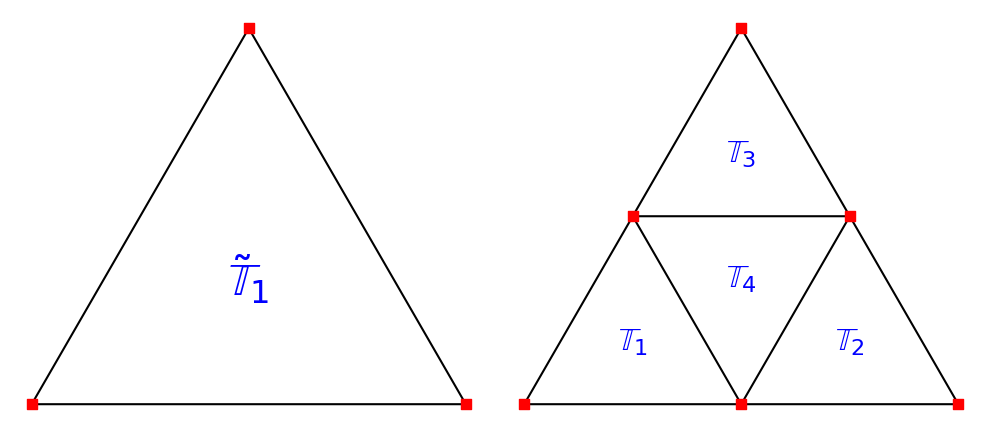

In [3]:
h = np.sqrt(3)/2
p = np.array([[0, 0],
              [1, 0],
              [1/2,h]])
e = np.array([[0,1,0],
              [1,2,0],
              [2,0,0]])
t = np.array([[0, 1, 2, 0, 1, 2, 0]])

pf, ef, tf = refine(p, e, t)
triangulation1 = tri.Triangulation(p[:, 0], p[:, 1], t[:, :3])
triangulation2 = tri.Triangulation(pf[:, 0], pf[:, 1], tf[:, :3])

_, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].triplot(triangulation1, c='k')
ax[1].triplot(triangulation2, c='k')

ax[0].scatter(p[:, 0],  p[:, 1],  s=50, facecolor='red', marker='s')
ax[1].scatter(pf[:, 0], pf[:, 1], s=50, facecolor='red', marker='s')

for i in [0,1]:
    ax[i].set_aspect('equal')
    ax[i].axis('off')

for idx, element in enumerate(t[:, :3]):

    triangle_coords = p[element]
    cx, cy = triangle_coords.mean(axis=0)
    
    ax[0].text(cx, cy, "$\\tilde{\mathbb{T}}_1$", fontsize=33, color='blue',
               fontweight='bold', ha='center', va='center')

for idx, element in enumerate(tf[:, :3]):

    triangle_coords = pf[element]
    cx, cy = triangle_coords.mean(axis=0)
    
    ax[1].text(cx, cy, fr"$\mathbb{{T}}_{{{idx + 1}}}$", fontsize=23, color='blue', 
           fontweight='bold', ha='center', va='center')
    
for i in [0, 1]:
    ax[i].set_aspect('equal')
    ax[i].axis('off')

plt.tight_layout()
plt.savefig("Outputs/P1-iso-P1.svg")
plt.show()

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #11116e">Jacobian Transformation</h3>
</div>

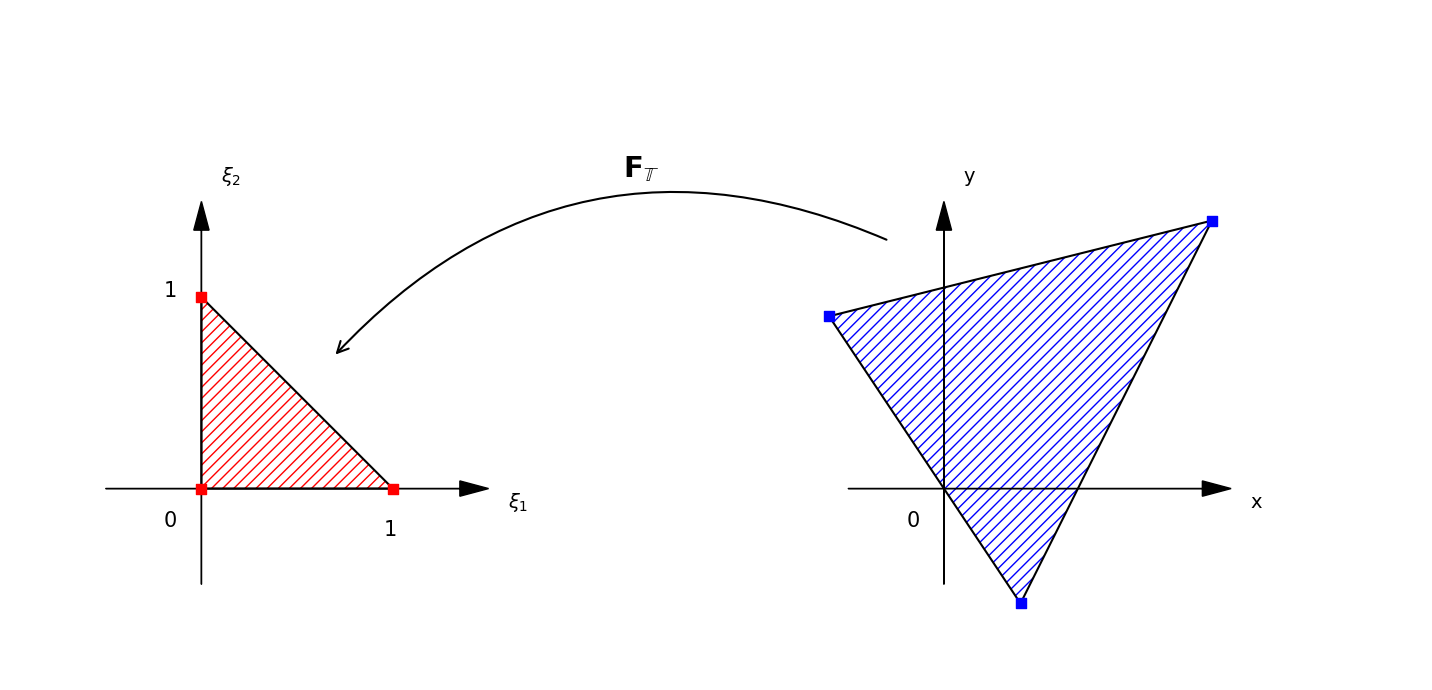

In [4]:
p = np.array([[0, 0], [1, 0], [0, 1]])
t = np.array([[0, 1, 2, 0, 1, 2, 0]])

p1 = np.array([[1, 1], [-1, 1/2], [0, -1]]) + 0.4
t1 = np.array([[0, 1, 2, 0, 1, 2, 0]])

triangulation1 = tri.Triangulation(p[:, 0], p[:, 1], t[:, :3])
triangulation2 = tri.Triangulation(p1[:, 0], p1[:, 1], t1[:, :3])

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

for triangle in triangulation1.triangles:
    coords = p[triangle]
    ax[0].fill(coords[:, 0], coords[:, 1], fill=False, hatch='///', edgecolor='red', linewidth=0)
ax[0].triplot(triangulation1, c='k', linewidth=1.5)
ax[0].scatter(p[:, 0],  p[:, 1],  s=50, facecolor='red', marker='s', zorder=3)

for triangle in triangulation2.triangles:
    coords = p1[triangle]
    ax[1].fill(coords[:, 0], coords[:, 1], fill=False, hatch='///', edgecolor='blue', linewidth=0)
ax[1].triplot(triangulation2, c='k', linewidth=1.5)
ax[1].scatter(p1[:, 0], p1[:, 1], s=50, facecolor='blue', marker='s', zorder=3)

for i, name in zip([0, 1], [[r'$\xi_1$', r'$\xi_2$'], ['x', 'y']]):
    ax[i].set_xlim(-1.8, 1.8)
    ax[i].set_ylim(-1.8, 1.8)
    
    ax[i].arrow(-0.5, 0, 2.0, 0, head_width=0.08, head_length=0.15, fc='k', ec='k', length_includes_head=True, zorder=1)
    ax[i].text(1.6, -0.1, name[0], fontsize=14)
    
    ax[i].arrow(0, -0.5, 0, 2.0, head_width=0.08, head_length=0.15, fc='k', ec='k', length_includes_head=True, zorder=1)
    ax[i].text(0.1, 1.6, name[1], fontsize=14)

    ax[i].text(-1/5, -1/5, r'$0$', fontsize=15)

    ax[i].set_ylim([-1.0, 2.5])
    ax[i].set_xlim([-1.0, 2.5])

ax[0].text(-1/5, 1, r'$1$', fontsize=15)
ax[0].text(1-0.05, -1/4, r'$1$', fontsize=15)

for i in [0, 1]:
    ax[i].set_aspect('equal')
    ax[i].axis('off')

xy_start = (0.7, 0.7)  
xy_end = (-0.3, 1.3)    

arrow = patches.ConnectionPatch(
    xyA=xy_start, xyB=xy_end, 
    coordsA="data", coordsB="data",
    axesA=ax[0], axesB=ax[1],
    arrowstyle="<-", mutation_scale=20, 
    connectionstyle="arc3,rad=-0.35",     
    color="black", lw=1.5, ls="-"
)
fig.add_artist(arrow)

mapping_text = r'$\mathbf{F}_{\mathbb{T}}$'
fig.text(0.45, 0.73, mapping_text, fontsize=21, ha='center', va='bottom')

plt.tight_layout()
plt.savefig("Outputs/Jacobian_tri_transform.svg")
plt.show();